# Bayesian Networks for early detection of Coronary Artery Disease

## 1 - Introduction

This project involves the construction of Bayesian networks utilizing the well known Cleveland dataset. This dataset represents a refined subset of the broader Heart Disease Database: a longitudinal collection originating from four distinct clinical institutions: Cleveland, Long Beach (CA), Hungary, and Switzerland. While the original database contains 76 attributes, this study focuses on a processed version comprising 13 key features.

Historically, this dataset was employed to evaluate novel probabilistic algorithms for the diagnosis of coronary artery disease. Specifically, the target variable, labeled 'condition', indicates the presence or absence of the pathology in the patient. The clinical parameters integrated into the dataset encompass:

* Electrocardiographic data: restecg, slope, and oldpeak.

* Anatomical and physiological markers: Number of major vessels (ca), resting blood pressure (trestbps), and fasting blood sugar (fbs).

* Biochemical and symptomatic indicators: Serum cholesterol (chol) and chest pain categories (exang, cp).

* Imaging/Nuclear Medicine: Thallium Scintigraphy (thal).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from pgmpy.causal_discovery import HillClimbSearch
from pgmpy.structure_score.aic import AIC
from pgmpy.estimators import BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
import networkx as nx

/Users/jacopomauro/Documents/git_repo_magistrale/FAIKR-mod3/bayesian-networks-on-heart-diseases/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jacopomauro/Documents/git_repo_magistrale/FAIKR-mod3/bayesian-networks-on-heart-diseases/.venv/lib/python3.14/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [2]:
df = pd.read_csv("datasets/cleveland_dataset.csv")
print(df.head())
print(df.describe())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  
              age         sex          cp    trestbps        chol         fbs  \
count  297.000000  297.000000  297.000000  297.000000  297.000000  297.000000   
mean    54.542088    0.676768    2.158249  131.693603  247.350168    0.144781   
std      9.049736    0.468500    0.964859   17.762806   51.997583    0.352474   
min     29.000000    0.000000    0.0000

## 2 - Data preprocessing

Upon analyzing the probability distributions of the dataset's features, it was observed that several variables were continuous in nature. However, the construction of Bayesian networks typically requires discrete (categorical) inputs to effectively estimate conditional probability tables.

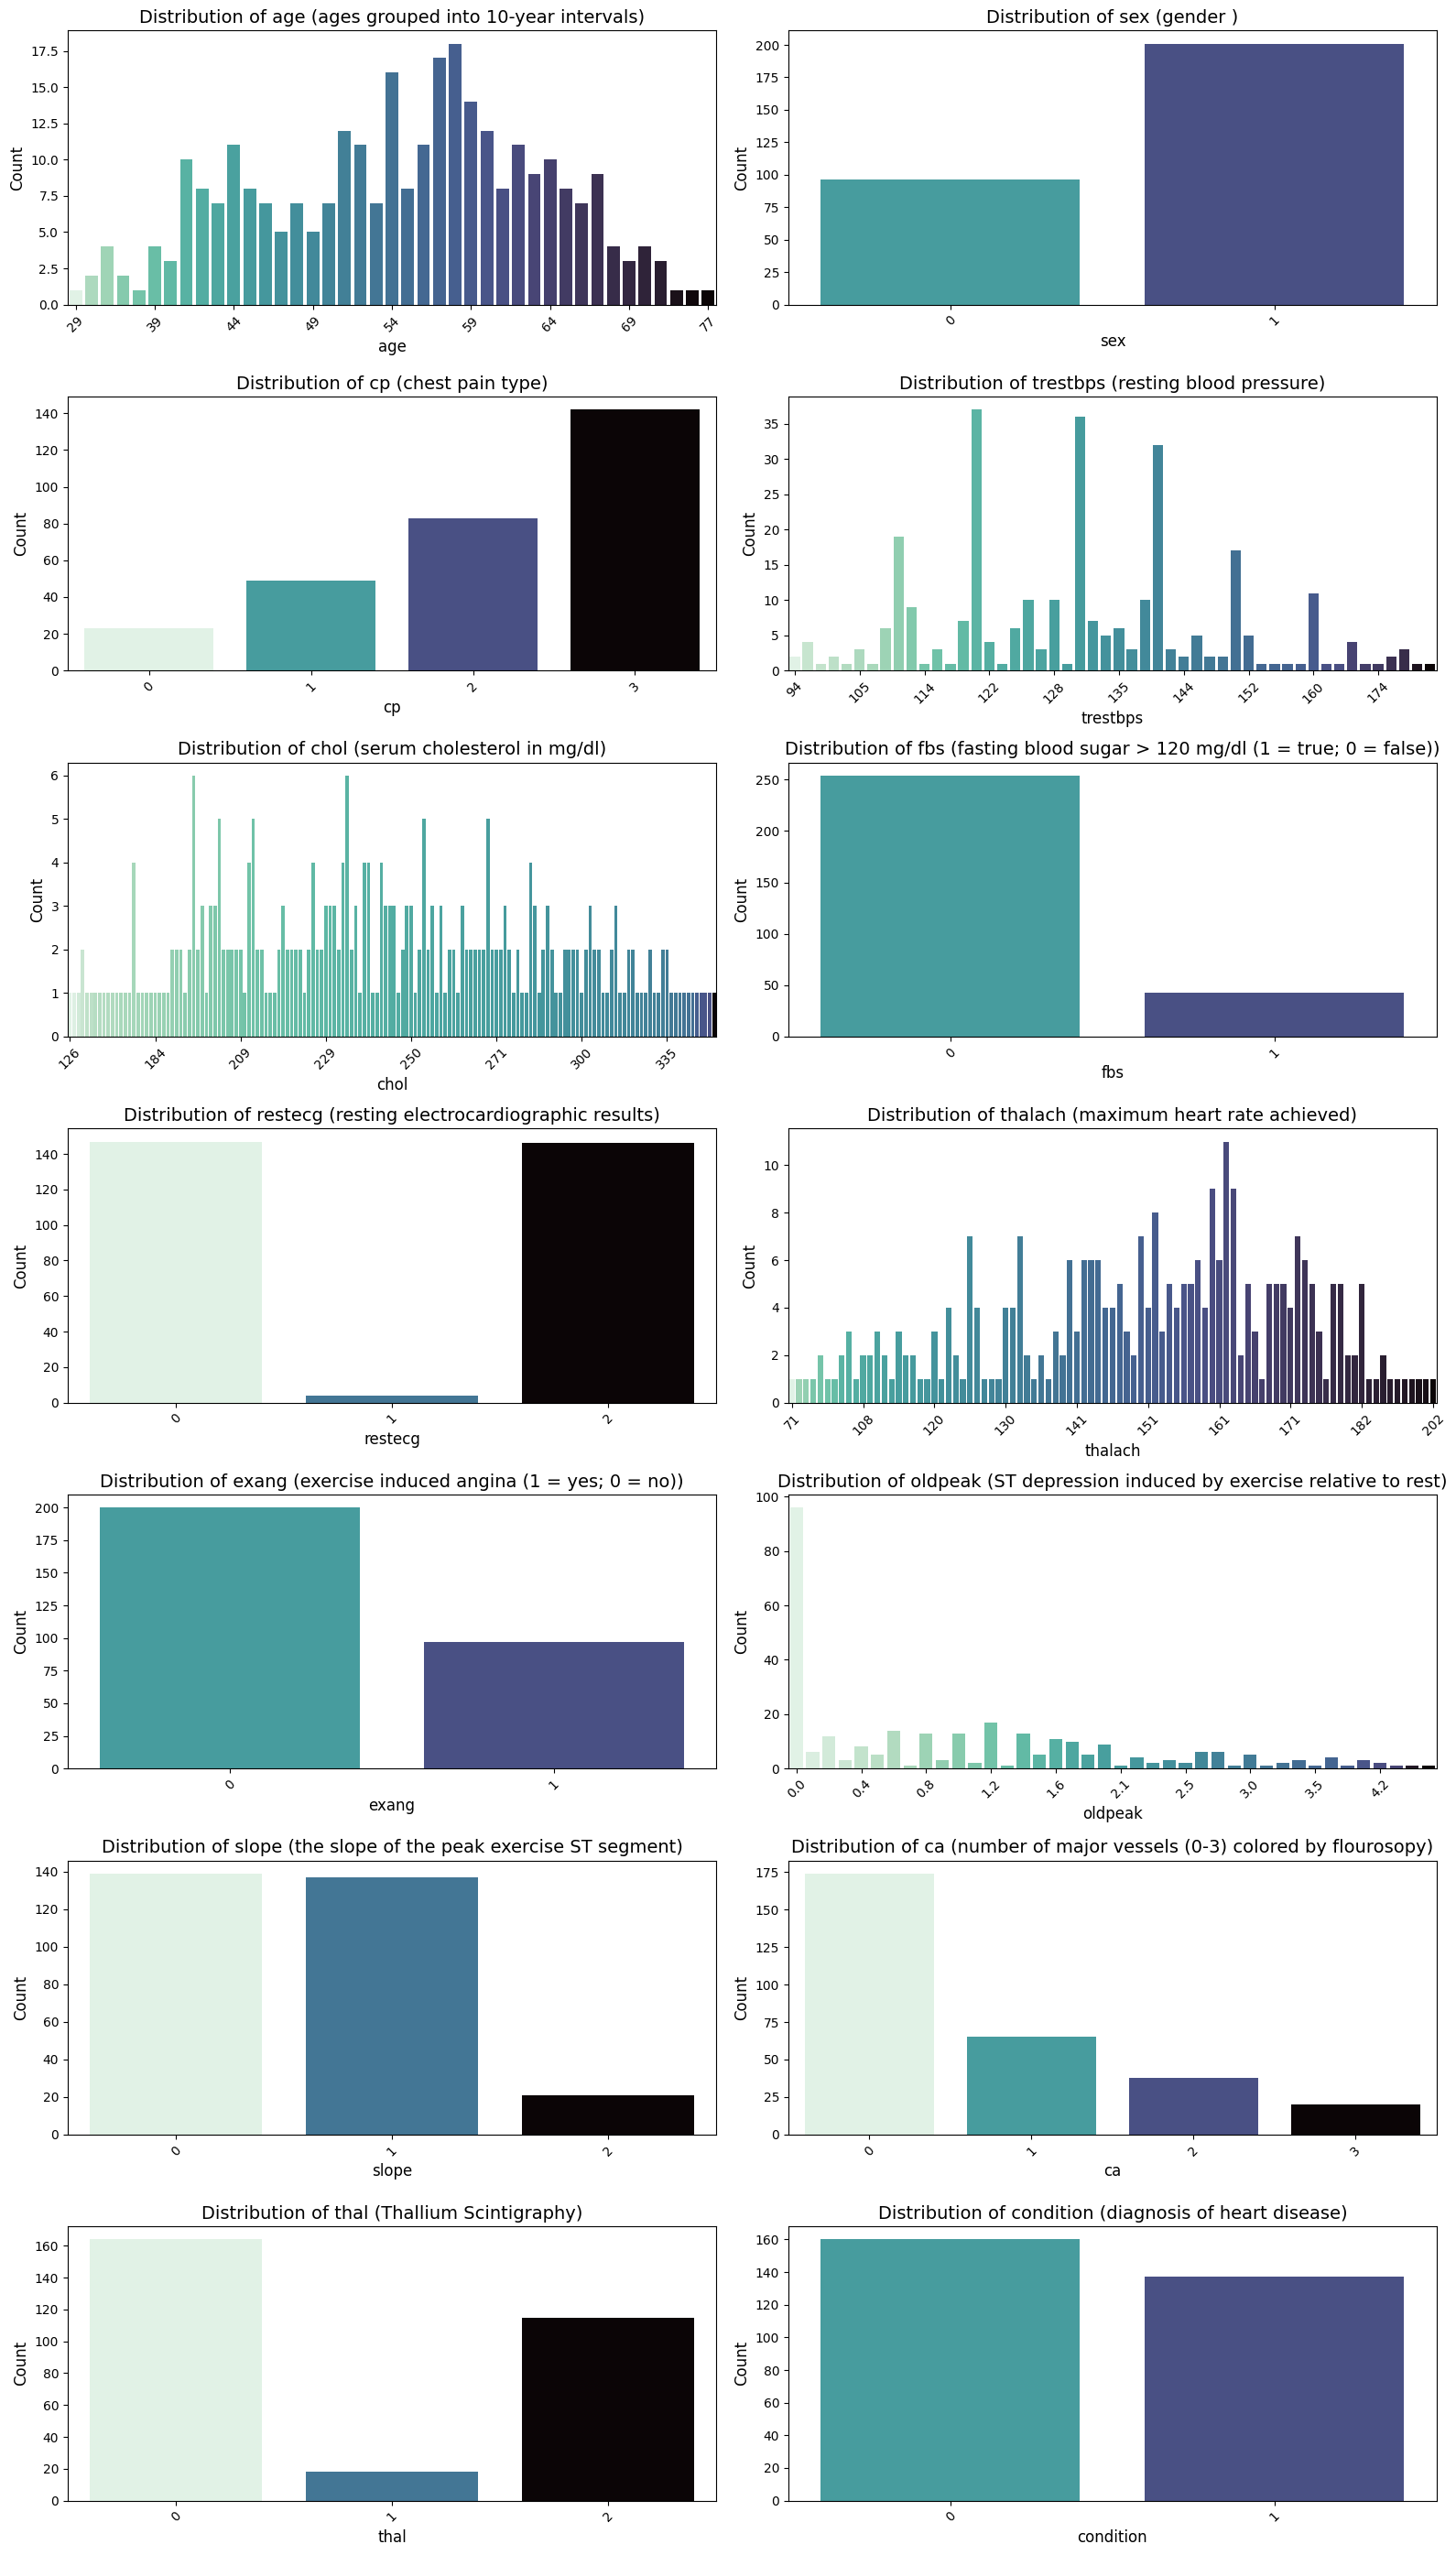

In [3]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(16, 28))
axes = axes.flatten()

column_descriptions = {
    'age': 'ages grouped into 10-year intervals',
    'sex': 'gender ',
    'cp': 'chest pain type',
    'trestbps': 'resting blood pressure',
    'chol': 'serum cholesterol in mg/dl',
    'fbs': 'fasting blood sugar > 120 mg/dl (1 = true; 0 = false)',
    'restecg': 'resting electrocardiographic results',
    'thalach': 'maximum heart rate achieved',
    'exang': 'exercise induced angina (1 = yes; 0 = no)',
    'oldpeak': 'ST depression induced by exercise relative to rest',
    'slope': 'the slope of the peak exercise ST segment',
    'ca': 'number of major vessels (0-3) colored by flourosopy',
    'thal': 'Thallium Scintigraphy',
    'condition': 'diagnosis of heart disease'
}

for i, column in enumerate(df.columns):
    sns.countplot(data=df, x=column, hue=column, ax=axes[i], palette='mako_r', legend=False)

    title = f'Distribution of {column}'
    if column in column_descriptions:
        title += f' ({column_descriptions[column]})'
    axes[i].set_title(title, fontsize=14)

    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    ticks = axes[i].get_xticks()
    if len(ticks) > 10:
        axes[i].xaxis.set_major_locator(plt.MaxNLocator(10)) 

plt.tight_layout()
plt.show();

### 2.1 - Discretization strategy
While standard techniques such as linear spacing (linspace) or equal-width binning are common in data preprocessing, they are often inadequate for medical diagnostics. These methods may fail to capture the clinically significant thresholds that distinguish healthy states from pathological ones. Consequently, we implemented a knowledge-based discretization strategy, aligning the feature intervals with established international medical guidelines.

The variables were categorized according to the following clinical standards:

* Serum Cholesterol (chol): Discretized based on the National Institutes of Health (NIH) guidelines, which define risk thresholds for lipid profiles. [[National Institutes of Health, page 3](https://www.nhlbi.nih.gov/files/docs/guidelines/atp3xsum.pdf)].

* Resting Blood Pressure (trestbps): Categorized according to the American Heart Association (AHA) classifications (e.g., Normal, Elevated, and Hypertensive stages). [[American Heart Association, "Definitions and Classification of BP"](https://www.ahajournals.org/doi/10.1161/HYP.0000000000000249)].

* Maximum Heart Rate Achieved (thalach): Adjusted by age-appropriate cohorts following the AHA "Target Heart Rate" standards. [[American Heart Association, "Maximum and Target Heart Rate by Age"](https://www.heart.org/en/healthy-living/fitness/fitness-basics/target-heart-rates)].

* Age: Grouped into intervals consistent with the Global Burden of Disease (GBD) study protocols published in The Lancet, ensuring demographic relevance. [[Global Burden of Disease Study (GBD) / The Lancet](https://www.thelancet.com/journals/lancet/article/PIIS0140-6736(18)31694-5/fulltext)].

* ST Depression (oldpeak): Classified based on diagnostic criteria established by The International Journal of Cardiovascular Imaging to identify significant myocardial ischemia. [[The International Journal of Cardiovascular Imaging](https://link.springer.com/article/10.1007/s10554-004-2458-y)].


By integrating these clinical benchmarks, the Bayesian network's nodes more accurately reflect the underlying physiological reality, thereby enhancing both the predictive accuracy and the clinical interpretability of the model.

In [4]:
df = pd.read_csv("datasets/cleveland_dataset.csv")
# Consolidate data discretization for 'trestbps', 'sex', 'chol', 'age', 'thalach', and 'oldpeak'

# Discretize 'trestbps'
bins_trestbps = [0, 119, 129, 139, 180, df['trestbps'].max() + 1]
labels_trestbps = ['0-118 Normal', '119-128 Elevated', '129-138 Hypertension Stage 1', '139-179 Hypertension Stage 2', '>=180 Hypertensive Crisis']
df['trestbps'] = pd.cut(df['trestbps'], bins=bins_trestbps, labels=labels_trestbps, right=False)

# Discretize 'sex'
labels_sex = ['Female', 'Male']
bins_sex = [0, 1, 2] # Assuming 0 and 1 are the only values
df['sex'] = pd.cut(df['sex'], bins=bins_sex, labels=labels_sex, right=False)

# Discretize 'chol'
bins_chol = [df['chol'].min(), 200, 240, df['chol'].max() + 1]
labels_chol = ['<200 Desirable', '200-239 Borderline High', '>=240 High']
df['chol'] = pd.cut(df['chol'], bins=bins_chol, labels=labels_chol, right=False)

# Discretize 'age'
bins_age = [df['age'].min(), 30, 40, 50, 60, 70, df['age'].max() + 1]
labels_age = ['20 - 29', '30 - 39', '40 - 49', '50 - 59', '60 - 69', '>= 70']
df['age'] = pd.cut(df['age'], bins=bins_age, labels=labels_age, right=False)

# Discretize 'thalach'
bins_thalach = [df['thalach'].min(), 120, 151, 181, df['thalach'].max() + 1]
labels_thalach = ['>=181 High', '151-180 Optimal', '120-150 Moderate', '<120 Poor Response'] # Reversed order
df['thalach'] = pd.cut(df['thalach'], bins=bins_thalach, labels=labels_thalach, right=False)

# Discretize 'oldpeak'
bins_oldpeak = [df['oldpeak'].min() - 0.001, 0.001, 1.0, 2.0, df['oldpeak'].max() + 1] # Adjusted to handle 0 as a distinct category
labels_oldpeak = ['0 Optimal', '0.1-0.9 Low Risk', '1.0-1.9 Moderate Risk', '>=2.0 High Risk']
df['oldpeak'] = pd.cut(df['oldpeak'], bins=bins_oldpeak, labels=labels_oldpeak, right=False)

print("Data after consolidating discretization:\n")
print("First 5 rows with 'trestbps', 'sex', 'chol', 'age', 'thalach', 'oldpeak' columns:")
display(df[['trestbps', 'sex', 'chol', 'age', 'thalach', 'oldpeak']].head())

print("\nValue counts for 'trestbps':")
display(df['trestbps'].value_counts())

print("\nValue counts for 'sex':")
display(df['sex'].value_counts())

print("\nValue counts for 'chol':")
display(df['chol'].value_counts())

print("\nValue counts for 'age':")
display(df['age'].value_counts())

print("\nValue counts for 'thalach':")
display(df['thalach'].value_counts())

print("\nValue counts for 'oldpeak':")
display(df['oldpeak'].value_counts())

Data after consolidating discretization:

First 5 rows with 'trestbps', 'sex', 'chol', 'age', 'thalach', 'oldpeak' columns:


,trestbps,sex,chol,age,thalach,oldpeak
0,139-179 Hypertension Stage 2,Male,200-239 Borderline High,60 - 69,151-180 Optimal,0.1-0.9 Low Risk
1,139-179 Hypertension Stage 2,Female,200-239 Borderline High,60 - 69,120-150 Moderate,1.0-1.9 Moderate Risk
2,139-179 Hypertension Stage 2,Female,200-239 Borderline High,60 - 69,>=181 High,>=2.0 High Risk
3,129-138 Hypertension Stage 1,Male,>=240 High,60 - 69,120-150 Moderate,1.0-1.9 Moderate Risk
4,0-118 Normal,Male,200-239 Borderline High,60 - 69,151-180 Optimal,1.0-1.9 Moderate Risk



Value counts for 'trestbps':


trestbps
139-179 Hypertension Stage 2    93
119-128 Elevated                71
129-138 Hypertension Stage 1    68
0-118 Normal                    60
>=180 Hypertensive Crisis        5
Name: count, dtype: int64


Value counts for 'sex':


...

age
50 - 59    121
60 - 69     81
40 - 49     71
30 - 39     13
>= 70       10
20 - 29      1
Name: count, dtype: int64


Value counts for 'thalach':


thalach
120-150 Moderate      143
151-180 Optimal       103
>=181 High             33
<120 Poor Response     18
Name: count, dtype: int64


Value counts for 'oldpeak':


oldpeak
0 Optimal                96
1.0-1.9 Moderate Risk    77
0.1-0.9 Low Risk         65
>=2.0 High Risk          59
Name: count, dtype: int64

The following plots illustrate the feature distributions after applying the medical discretization thresholds.

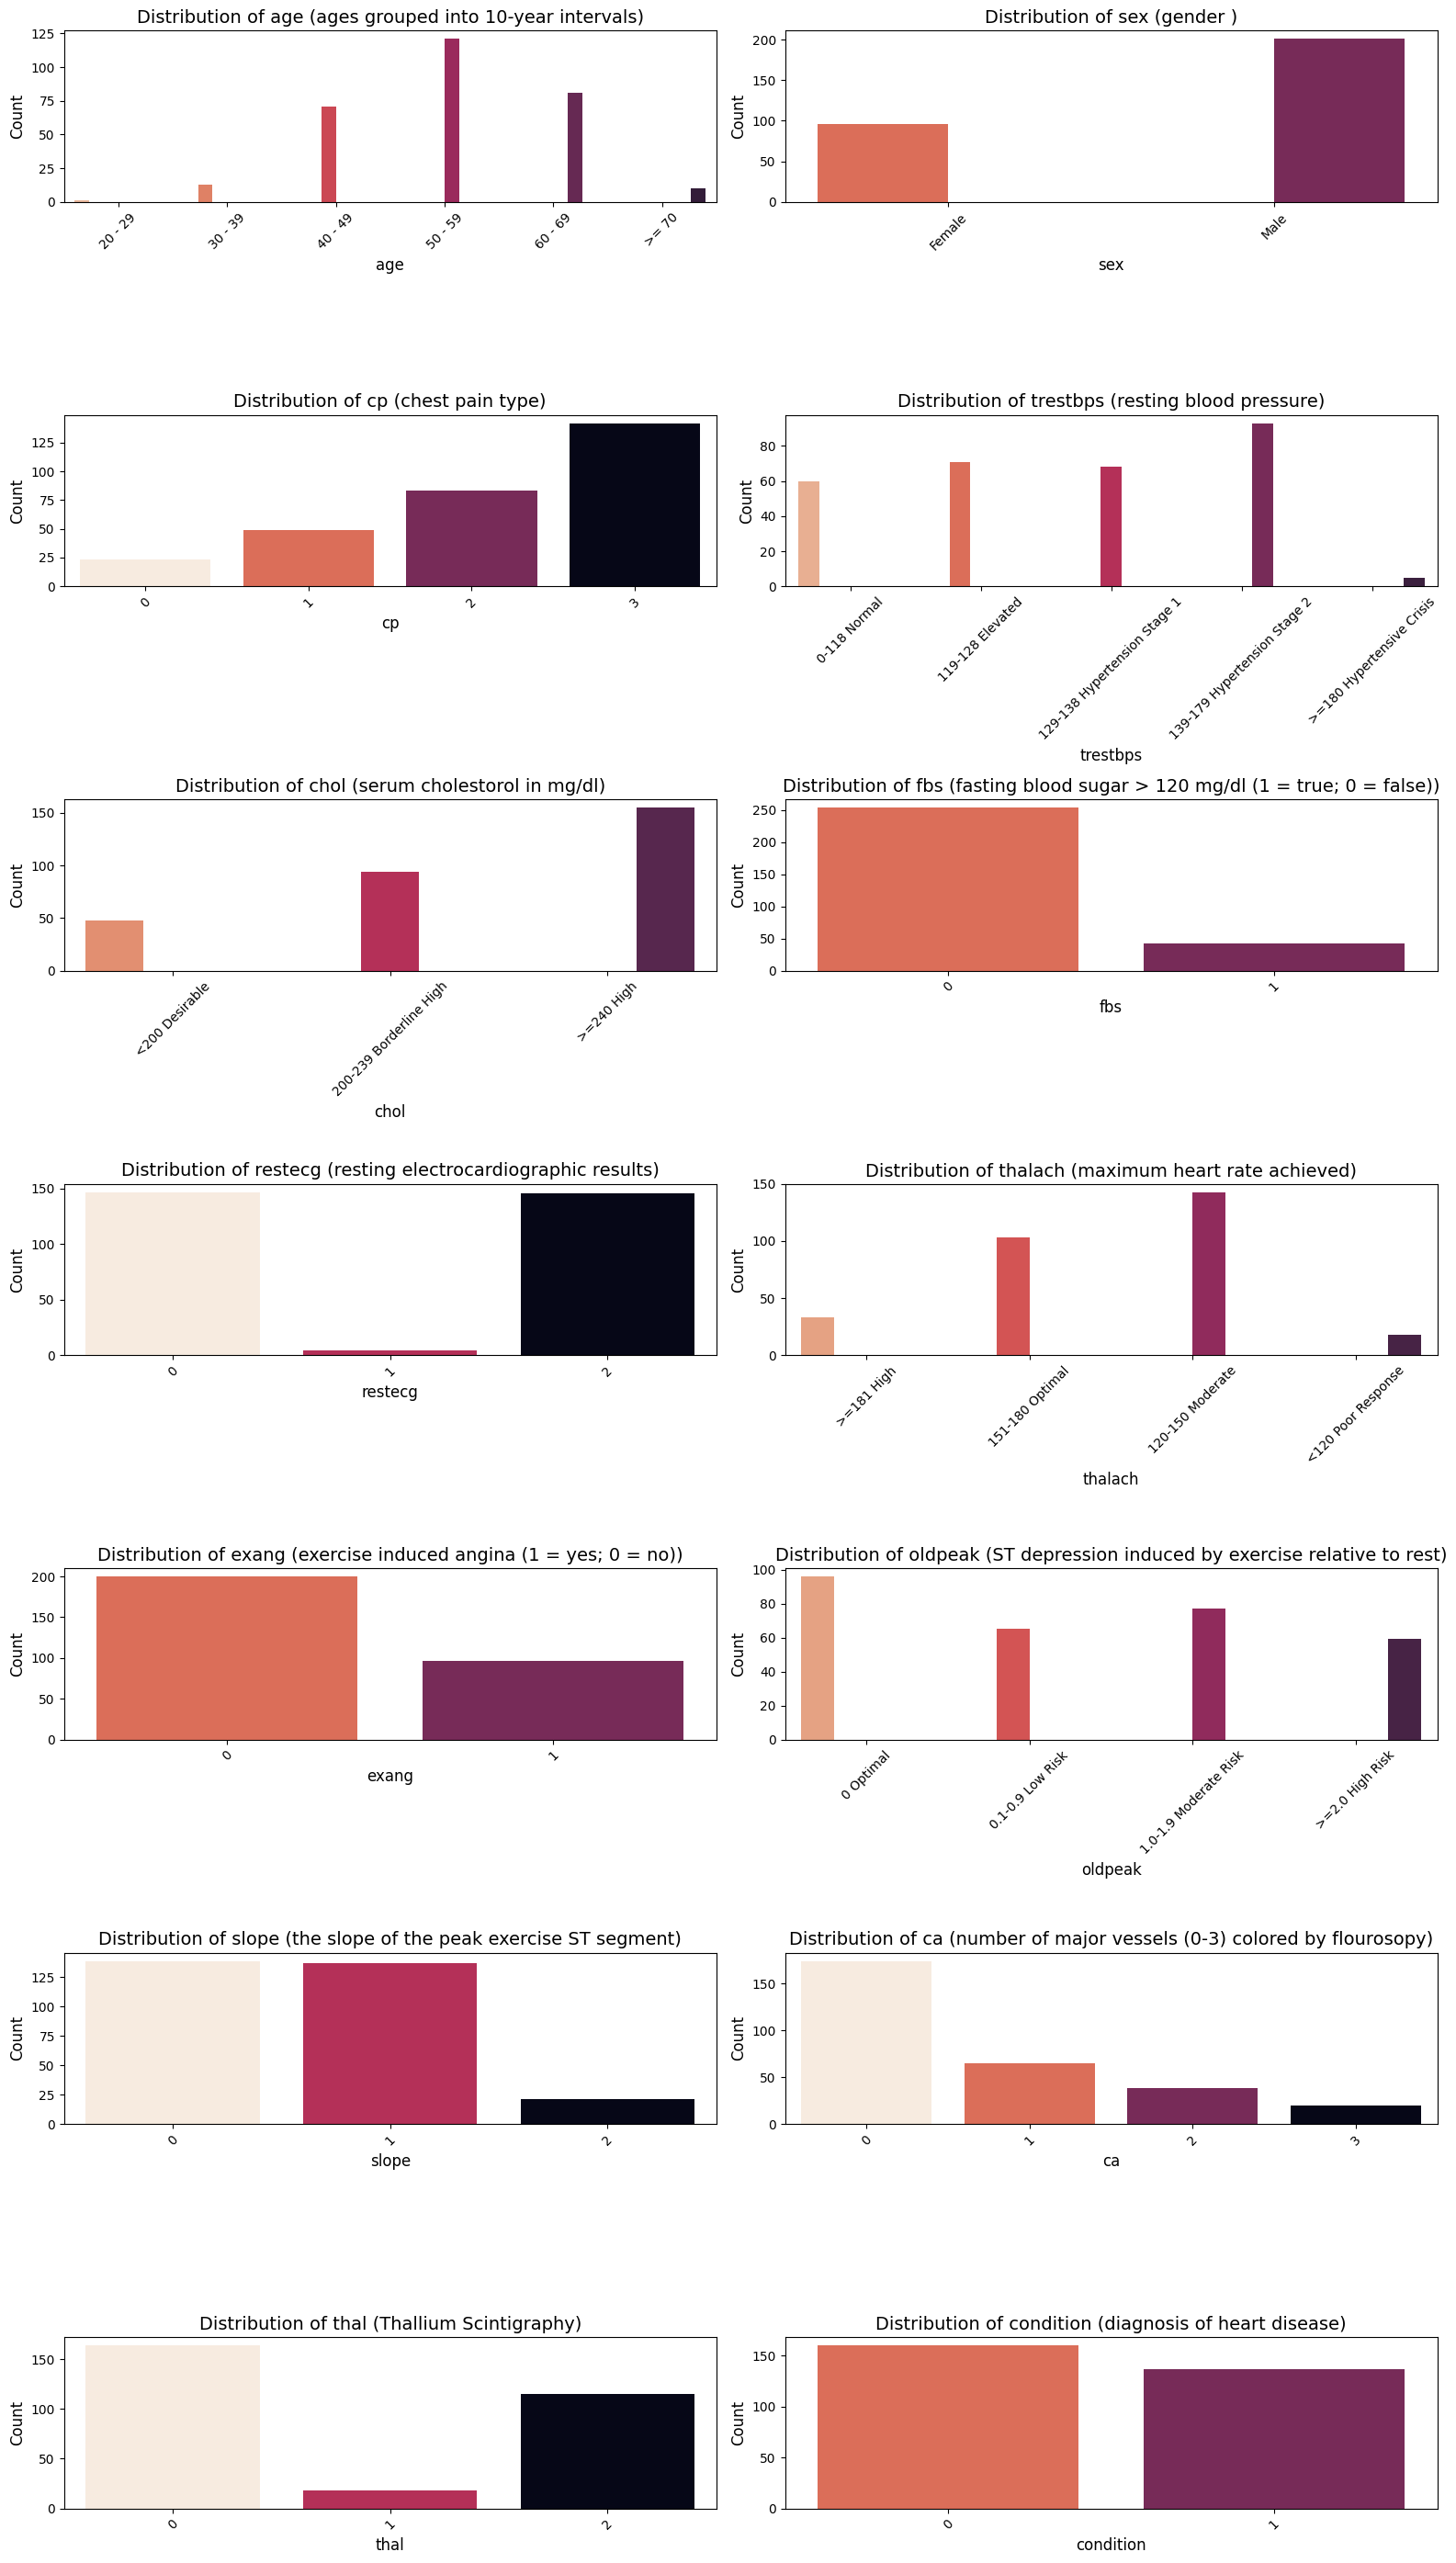

In [5]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(16, 28))
axes = axes.flatten()

column_descriptions = {
    'age': 'ages grouped into 10-year intervals',
    'sex': 'gender ',
    'cp': 'chest pain type',
    'trestbps': 'resting blood pressure',
    'chol': 'serum cholestorol in mg/dl',
    'fbs': 'fasting blood sugar > 120 mg/dl (1 = true; 0 = false)',
    'restecg': 'resting electrocardiographic results',
    'thalach': 'maximum heart rate achieved',
    'exang': 'exercise induced angina (1 = yes; 0 = no)',
    'oldpeak': 'ST depression induced by exercise relative to rest',
    'slope': 'the slope of the peak exercise ST segment',
    'ca': 'number of major vessels (0-3) colored by flourosopy',
    'thal': 'Thallium Scintigraphy',
    'condition': 'diagnosis of heart disease'
}

for i, column in enumerate(df.columns):
    sns.countplot(data=df, x=column, hue=column, ax=axes[i], palette='rocket_r', legend=False)

    title = f'Distribution of {column}'
    if column in column_descriptions:
        title += f' ({column_descriptions[column]})'
    axes[i].set_title(title, fontsize=14)

    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show();

# 3 - Bayesan Networks

### Model Training and Iterative Optimization

We developed several network architectures, applying incremental adjustments in each iteration. The initial model was trained without structural constraints, utilizing the Akaike Information Criterion (AIC) via the pgmpy library. The AIC was preferred over the Bayesian Information Criterion (BIC) as it is less restrictive, facilitating the identification of a more complex set of dependencies (edges) between the nodes.

  0%|          | 18/10000 [00:00<03:07, 53.22it/s]
/var/folders/x4/1ks2qnkx2hb9k29f09fmmm7r0000gn/T/ipykernel_17115/3181518009.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Struttura stimata: [('age', 'trestbps'), ('age', 'fbs'), ('sex', 'chol'), ('cp', 'condition'), ('cp', 'oldpeak'), ('thalach', 'thal'), ('exang', 'cp'), ('exang', 'thalach'), ('exang', 'condition'), ('oldpeak', 'slope'), ('oldpeak', 'thalach'), ('oldpeak', 'restecg'), ('ca', 'age'), ('thal', 'sex'), ('condition', 'thal'), ('condition', 'ca'), ('condition', 'oldpeak'), ('condition', 'sex')]
Accuracy: 0.85
              precision    recall  f1-score   support

           0       0.79      0.97      0.87        32
           1       0.95      0.71      0.82        28

    accuracy                           0.85        60
   macro avg       0.87      0.84      0.84        60
weighted avg       0.87      0.85      0.85        60



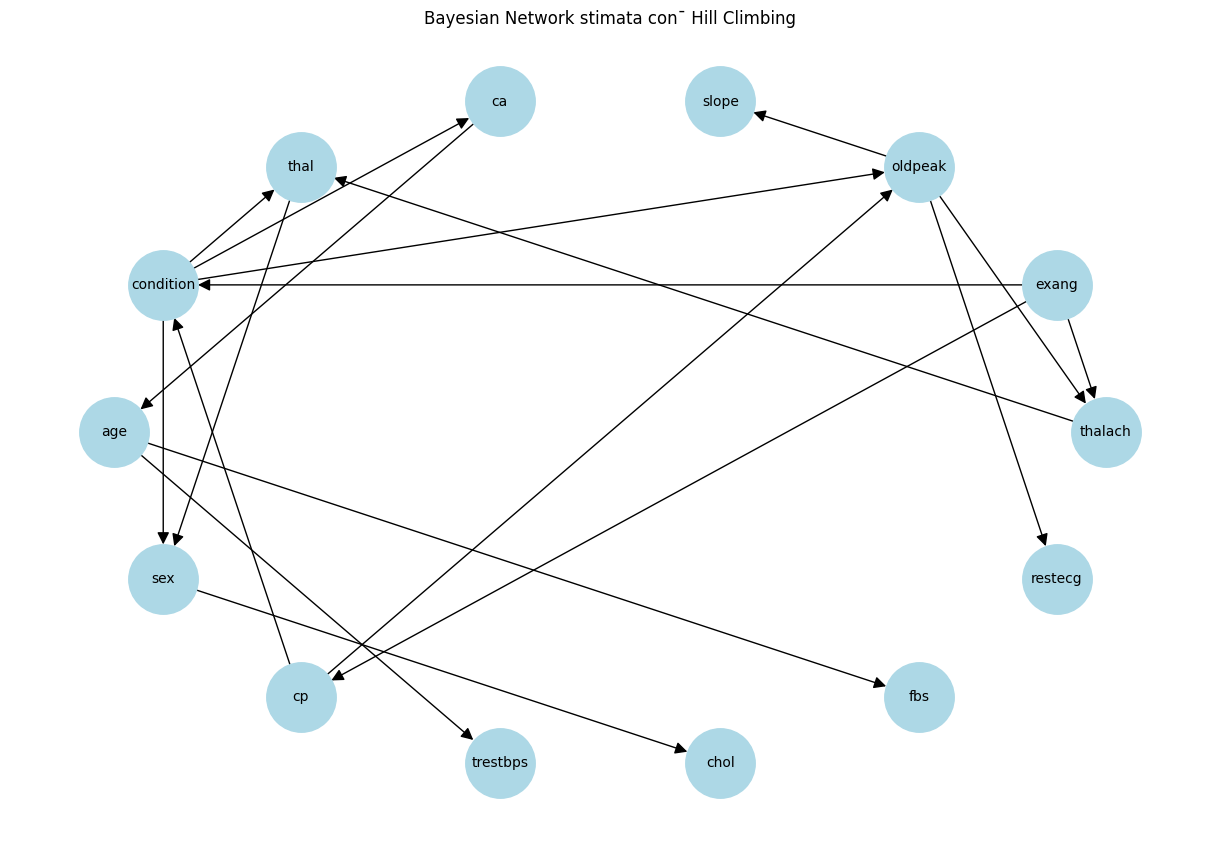

In [6]:

# Split train/test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["condition"])

# Apprendimento struttura con Hill Climbing
score = AIC(train_df)
hc = HillClimbSearch(scoring_method=score, max_indegree=3, max_iter=10000, return_type="dag")
hc.fit(train_df)
model = hc.causal_graph_
print("Struttura stimata:", list(model.edges()))

# Fit dei parametri su rete discreta
bn = DiscreteBayesianNetwork()
bn.add_nodes_from(model.nodes())
bn.add_edges_from(model.edges())
bn.fit(train_df, estimator=BayesianEstimator, prior_type="BDeu")

# Inferenza e predizione
infer = VariableElimination(bn)
features = [c for c in df.columns if c != "condition"]
preds = []
for _, row in test_df.iterrows():
    q = infer.query(["condition"], evidence=row[features].to_dict(), show_progress=False)
    preds.append(int(q.values.argmax()))

print("Accuracy:", accuracy_score(test_df["condition"].astype(int), preds))
print(classification_report(test_df["condition"].astype(int), preds, zero_division=0))

# Plot rete bayesiana
plt.figure(figsize=(12, 8))
pos = nx.shell_layout(model)
nx.draw(model, pos=pos, with_labels=True, node_size=2500, node_color="lightblue", font_size=10, arrowsize=18)
plt.title("Bayesian Network stimata con¯ Hill Climbing")
plt.tight_layout()
plt.show()

Looking at the initial network, we observe that the algorithm successfully identified several dependencies, confirming that all features in the dataset contribute to the study. Specifically, both cp (chest pain type) and exang (exercise-induced angina) are identified as direct causes of the heart condition. However, some of the estimated connections lack clinical plausibility. To address these inconsistencies and align the model with medical reality, we introduced structural constraints in the following step.

### 3.1 - Structural Constraints and Domain Knowledge
In the subsequent iteration, we introduced a "blacklist" to enforce logical constraints on the network structure. This list contains tuples of nodes between which a causal dependency is biologically or logically impossible.

For instance, physiological markers such as blood pressure cannot influence demographic variables like age. Consequently, the blacklist was configured to prohibit any incoming edges directed toward the age or sex nodes, ensuring that these variables function exclusively as independent root nodes or exogenous factors within the model.

  0%|          | 17/10000 [00:00<03:06, 53.55it/s]
/var/folders/x4/1ks2qnkx2hb9k29f09fmmm7r0000gn/T/ipykernel_17115/315528944.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Struttura stimata: [('age', 'trestbps'), ('age', 'fbs'), ('sex', 'thal'), ('sex', 'condition'), ('sex', 'chol'), ('sex', 'exang'), ('cp', 'condition'), ('cp', 'oldpeak'), ('fbs', 'ca'), ('exang', 'cp'), ('exang', 'thalach'), ('oldpeak', 'slope'), ('oldpeak', 'thalach'), ('oldpeak', 'restecg'), ('condition', 'thal'), ('condition', 'ca'), ('condition', 'oldpeak')]
Accuracy: 0.7833333333333333
              precision    recall  f1-score   support

           0       0.81      0.78      0.79        32
           1       0.76      0.79      0.77        28

    accuracy                           0.78        60
   macro avg       0.78      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



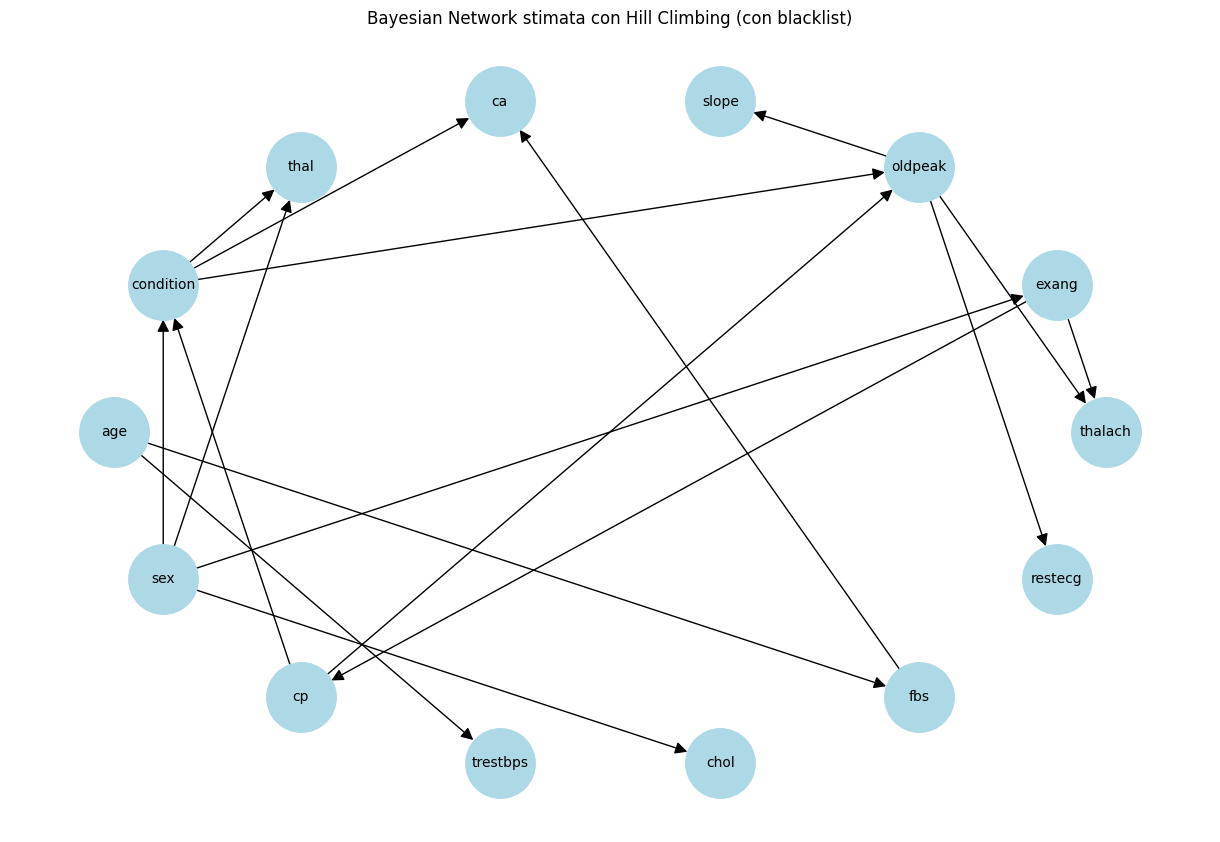

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from pgmpy.causal_discovery import HillClimbSearch, ExpertKnowledge
from pgmpy.structure_score.aic import AIC
from pgmpy.estimators import BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
import networkx as nx


# Split train/test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["condition"])

all_nodes = list(df.columns)
features = [c for c in df.columns if c != "condition"]
blacklist = []
for node in ['age', 'sex']:
    for from_node in [n for n in all_nodes if n != node]:
        blacklist.append((from_node, node))

expert_knowledge = ExpertKnowledge(forbidden_edges=blacklist)

score = AIC(train_df)
hc = HillClimbSearch(scoring_method=score, max_indegree=3, max_iter=10000, return_type="dag", expert_knowledge=expert_knowledge)
hc.fit(train_df)
model = hc.causal_graph_
print("Struttura stimata:", list(model.edges()))

bn = DiscreteBayesianNetwork()
bn.add_nodes_from(model.nodes())
bn.add_edges_from(model.edges())
bn.fit(train_df, estimator=BayesianEstimator, prior_type="BDeu")

infer = VariableElimination(bn)
preds = []
for _, row in test_df.iterrows():
    q = infer.query(["condition"], evidence=row[features].to_dict(), show_progress=False)
    preds.append(int(q.values.argmax()))

print("Accuracy:", accuracy_score(test_df["condition"].astype(int), preds))
print(classification_report(test_df["condition"].astype(int), preds, zero_division=0))

plt.figure(figsize=(12, 8))
pos = nx.shell_layout(model)
nx.draw(model, pos=pos, with_labels=True, node_size=2500, node_color="lightblue", font_size=10, arrowsize=18)
plt.title("Bayesian Network stimata con Hill Climbing (con blacklist)")
plt.tight_layout()
plt.show()

The refined network now demonstrates greater clinical plausibility. To further enhance the model's diagnostic and predictive depth, the next step involves the introduction of latent variables. 

## 3.2 - Integration of Clinical Domain Knowledge

To further refine the causal structure, we explicitly enforced mandatory dependencies based on established medical literature. This process ensures that the Bayesian Network respects well-documented physiological mechanisms that might be underrepresented in the raw data.

The following causal relationships were integrated into the model:

* Age -> Trestbps: Aging is a primary driver of increased arterial stiffness and resting systolic blood pressure. [[The impact of aging on blood pressure](https://pmc.ncbi.nlm.nih.gov/articles/PMC9521719/)]
* Exang -> Oldpeak: Exercise-induced angina often precedes or coincides with significant ST-segment depression, reflecting the heart's response to ischemic stress.[[ST-segment depression and angina pectoris](https://pubmed.ncbi.nlm.nih.gov/8314646/)]
* CA -> Condition: The number of major vessels colored by fluoroscopy (CA) is a direct diagnostic indicator of the presence and severity of coronary artery disease. [[Fluoroscopy in the diagnosis of CAD](https://www.ahajournals.org/doi/10.1161/01.CIR.49.6.1247)]



INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from 

  Fold 1: Accuracy=0.633, Recall=0.571


  0%|          | 0/1000000 [00:00<?, ?it/s]

...

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from 

  Fold 4: Accuracy=0.814, Recall=0.741


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'N', 'trestbps': 'O', 'chol': 'O', 'fbs': 'N', 'restecg': 'N', 'thalach': 'O', 'exang': 'N', 'oldpeak': 'O', 'slope': 'N', 'ca': 'N', 'thal': 'N', 'condition': 'N'}


  Fold 5: Accuracy=0.831, Recall=0.852
  MEAN -> Accuracy=0.782, Recall=0.746



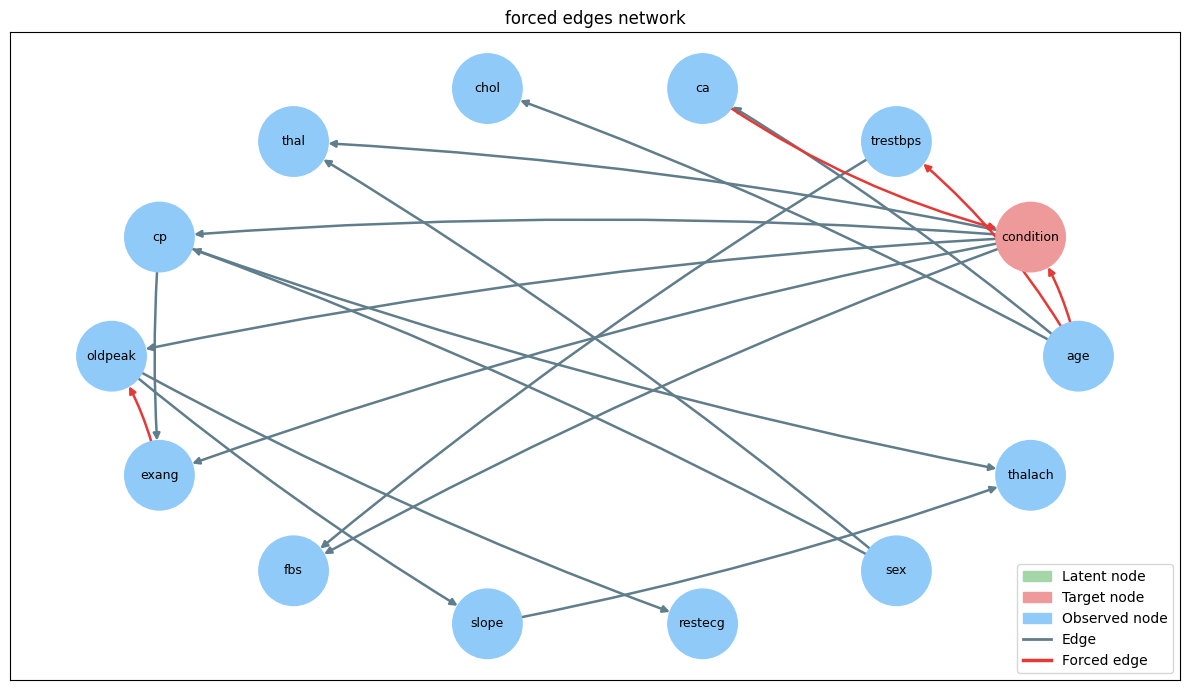

accuracy:  0.7816384180790961
recall:  0.7455026455026456


In [ ]:
parent_variables = ['sex', 'age']
forbidden_edges = [(col, root) for root in parent_variables for col in df.columns if col != root]

forced_edges = [('age', 'condition'),
                ('age', 'trestbps'),
                ('exang', 'oldpeak'),
                ('ca', 'condition'),]

acc_forced, recall_forced, forced_model = kfold_latent(df, forbidden_edges, forced_edges, [], target_col='condition')

plot_latent_network(forced_model.edges(), forced_edges=forced_edges, latent_nodes=[], target='condition', title='forced edges network', legend_loc='lower right')

print("accuracy: ", acc_forced)
print("recall: ", recall_forced)

## 3.3 - Introduction of Latent Variables

To capture complex physiological patterns that are not explicitly labeled in the dataset, we introduced two latent variables. These variables act as unobserved "parent" nodes that synthesize information from multiple clinical markers, providing a more holistic view of a patient's health status.

Based on cardiovascular research, we defined:

* Coronary Heart Status: This latent node summarizes the heart's functional response to stress. It integrates markers of myocardial ischemia and physical performance, specifically linking oldpeak (ST depression), slope, and thalach (max heart rate).[[Coronary Health](https://www.ncbi.nlm.nih.gov/books/NBK557672/)].
* Metabolic Risk Factor: This node accounts for the patient's metabolic profile by grouping chol (cholesterol) and fbs (fasting blood sugar). This aligns with the "Metabolic Syndrome" framework, where dyslipidemia and hyperglycemia act synergistically to increase cardiovascular risk.[[Metabolic risk](https://pmc.ncbi.nlm.nih.gov/articles/PMC3045098/)].


To evaluate the impact of these hidden structures on the network's predictive power, we implemented and compared three distinct configurations:
* Model 1: Includes only the *Coronary Heart Status* latent variable.
* Model 2: Includes only the *Metabolic Risk Factor* latent variable.
* Model 3: Integrates both latent variables simultaneously plus the previous clinical domain knowledge to test their combined effect on the target condition.


Obviosly for each latent variable we needed to add forced edges connected to the new node.

In [8]:
from network_functions import plot_latent_network

from pgmpy.inference import VariableElimination
from sklearn.metrics import accuracy_score, recall_score
from sklearn.model_selection import StratifiedKFold

In [9]:
# Function to build a latent variable model with structure learning 
def build_latent_model(train_df,
                       forbidden_edges=[],
                       forced_edges=[],
                       latent_nodes=[],
                       latent_card=2):
    """
    Build and fit a Bayesian network with latent nodes.

    Behavior:
    - Use HillClimbSearch + BIC to learn structure among observed variables.
    - Pass observed-only forced/forbidden edges to the hill-climb via ExpertKnowledge.
    - Combine learned observed-edges with forced edges that involve latent nodes.
    - Create a DiscreteBayesianNetwork declaring `latent_nodes` as latents and estimate
      CPDs with Expectation-Maximization (EM).

    Parameters:
        train_df (pd.DataFrame): Discretized training data (observed variables; EM expects string states).
        forbidden_edges (list of (u,v)): Edges to forbid (may include latent nodes).
        forced_edges (list of (u,v)): Edges to force (should include latent-node edges if any).
        latent_nodes (list): Names of latent variables (strings).
        latent_card (int or dict): Cardinality for each latent node (int applied to all, or dict {node:card}).

    Returns:
        pgmpy.models.BayesianNetwork: Fitted DiscreteBayesianNetwork with CPDs added.
    """
    # Local imports for copy-paste convenience
    from pgmpy.estimators import HillClimbSearch, BIC, ExpectationMaximization, ExpertKnowledge
    from pgmpy.models import DiscreteBayesianNetwork

    # Normalize to tuple pairs
    forced_edges = [tuple(e) for e in forced_edges]
    forbidden_edges = [tuple(e) for e in forbidden_edges]

    # Observed columns (data should NOT contain latent nodes)
    observed_cols = [c for c in train_df.columns if c not in latent_nodes]

    # Split forced/forbidden into observed-only vs latent-involving
    forced_obs = [e for e in forced_edges if (e[0] in observed_cols) and (e[1] in observed_cols)]
    forced_latent = [e for e in forced_edges if (e[0] in latent_nodes) or (e[1] in latent_nodes)]

    forbidden_obs = [e for e in forbidden_edges if (e[0] in observed_cols) and (e[1] in observed_cols)]
    # forbidden_latent not used here (user said they will handle conflicts)

    # 1) Learn structure among observed variables using hill-climb with expert knowledge
    learned_edges = []
    try:
        if len(observed_cols) >= 2:
            hc = HillClimbSearch(train_df[observed_cols])
            score = BIC(train_df[observed_cols])
            # pass observed-only forced/forbidden edges to ExpertKnowledge
            ek = ExpertKnowledge(required_edges=forced_obs, forbidden_edges=forbidden_obs)
            best_model = hc.estimate(scoring_method=score, expert_knowledge=ek)
            learned_edges = [tuple(e) for e in best_model.edges()]
    except Exception as exc:
        print(f"Warning: structure learning failed; falling back to forced edges only. Error: {exc}")
        learned_edges = []

    # 2) Combine edges: keep forced latent edges + forced observed edges + learned observed edges
    combined = list(forced_latent) + list(forced_obs) + list(learned_edges)
    # simple dedup while preserving order
    seen = set()
    final_edges = []
    for e in combined:
        if e not in seen:
            seen.add(e)
            final_edges.append(e)

    # 3) Build model, declare latents, add missing observed nodes
    model = DiscreteBayesianNetwork(final_edges, latents=latent_nodes)
    missing_obs = set(observed_cols) - set(model.nodes())
    if missing_obs:
        model.add_nodes_from(missing_obs)
    for ln in latent_nodes:
        if ln not in model.nodes():
            model.add_node(ln)

    # 4) Estimate CPDs using EM
    if isinstance(latent_card, dict):
        latent_card_dict = latent_card
    else:
        latent_card_dict = {n: latent_card for n in latent_nodes}

    em = ExpectationMaximization(model, train_df)
    cpds = em.get_parameters(
        latent_card=latent_card_dict,
        max_iter=100,
        show_progress=False,
        seed=42
    )
    model.add_cpds(*cpds)
    model.check_model()
    return model



def evaluate_latent_model(model, val_df, target_col='target', latent_nodes=[]):
    """
    Assumes the target column contains integer labels 0/1 (no extra checks).
    Returns: (accuracy, roc_auc)
    """

    missing = (set(val_df.columns) - set(model.nodes())) | set(latent_nodes)
    infer = VariableElimination(model)
    y_prob, y_true = [], []

    for _, row in val_df.reset_index(drop=True).iterrows():
        evidence = {c: row[c] for c in val_df.columns if c not in missing and c != target_col}
        try:
            q = infer.query([target_col], evidence=evidence, show_progress=False)
            states = q.state_names[target_col]
            p1 = float(q.values[states.index(1)])
        except Exception:
            p1 = 0.5
        y_prob.append(p1)
        y_true.append(int(row[target_col]))  # assumes 0/1 integers

    y_prob = np.array(y_prob)
    y_true = np.array(y_true)
    y_pred = (y_prob >= 0.5).astype(int)

    return accuracy_score(y_true, y_pred), recall_score(y_true, y_pred)



def kfold_latent(df, forbidden_edges=[], forced_edges=[], latent_nodes=[], n_splits=5, target_col='target'):
    """K-fold cross-validation for a latent BN."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    y = df[target_col]
    accs, recalls = [], []
    best_model = None
    best_acc = 0
    for fold, (train_idx, val_idx) in enumerate(skf.split(df, y)):
        train_df = df.iloc[train_idx].copy()
        val_df   = df.iloc[val_idx].copy()
        model = build_latent_model(train_df, forbidden_edges=forbidden_edges, forced_edges=forced_edges, latent_nodes=latent_nodes)
        acc, recall = evaluate_latent_model(model, val_df, latent_nodes=latent_nodes, target_col=target_col)
        accs.append(acc)
        recalls.append(recall)
        print(f"  Fold {fold+1}: Accuracy={acc:.3f}, Recall={recall:.3f}")
        if acc > best_acc:
            best_model = model
    mean_acc = np.mean(accs)
    mean_recall = np.mean(recalls)
    print(f"  MEAN -> Accuracy={mean_acc:.3f}, Recall={mean_recall:.3f}\n")
    return mean_acc, mean_recall, best_model

### Network 1

In [ ]:
parent_variables = ['sex', 'age']
forbidden_edges = [(col, root) for root in parent_variables for col in df.columns if col != root]

forced_edges_1 = [('coronary_health', 'oldpeak'),
                ('coronary_health', 'exang'),
                ('coronary_health', 'slope'),
                ('coronary_health', 'condition'),]

latent_nodes_1 = ['coronary_health']

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
/home/liam/pythonEnvs/env1/lib/python3.11/site-packages/pgmpy/factors/discrete/DiscreteFactor.py:489: RuntimeWarning: invalid value encountered in divide
  phi.values = phi.values / (phi.values.sum())
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C'

  Fold 1: Accuracy=0.667, Recall=0.607


  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  Fold 4: Accuracy=0.780, Recall=0.704


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}


  Fold 5: Accuracy=0.797, Recall=0.741
  MEAN -> Accuracy=0.761, Recall=0.716



/home/liam/pythonEnvs/env1/lib/python3.11/site-packages/pgmpy/factors/discrete/DiscreteFactor.py:489: RuntimeWarning: invalid value encountered in divide
  phi.values = phi.values / (phi.values.sum())


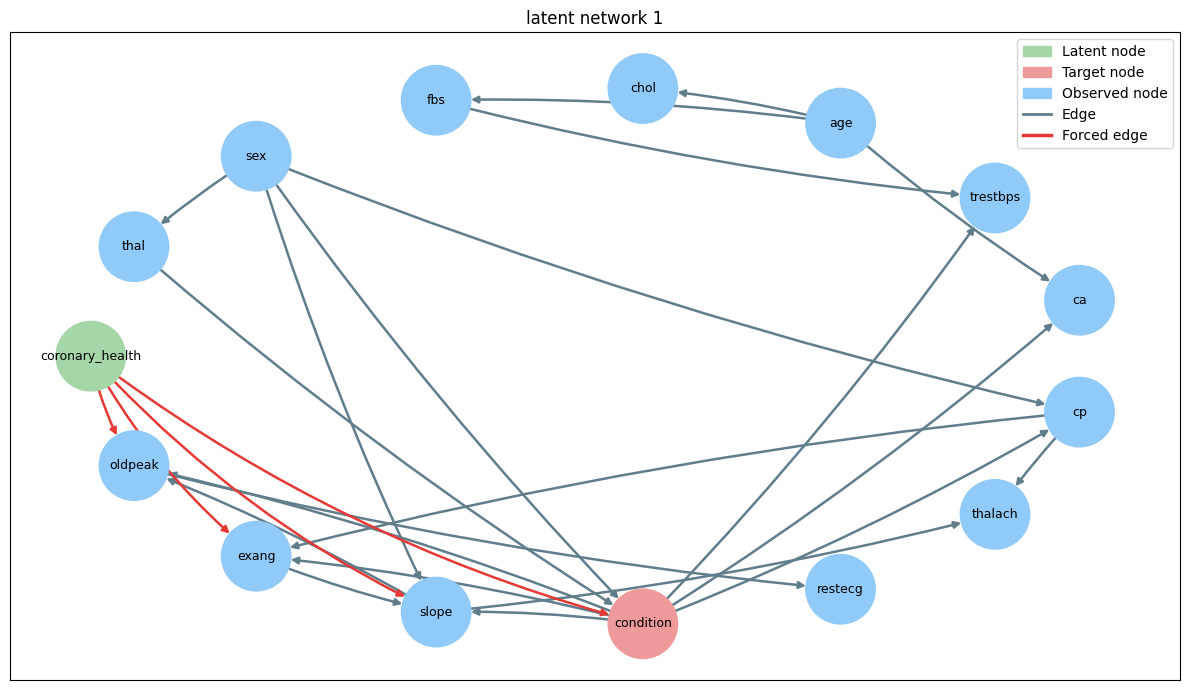

In [ ]:
acc_1, recall_1, latent_model_1 = kfold_latent(df, forbidden_edges, forced_edges_1, latent_nodes_1, target_col='condition')

plot_latent_network(latent_model_1.edges(), forced_edges=forced_edges_1, latent_nodes=latent_nodes_1, target='condition', title='latent network 1', legend_loc='upper right')

### Network 2

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
/home/liam/pythonEnvs/env1/lib/python3.11/site-packages/pgmpy/factors/discrete/DiscreteFactor.py:489: RuntimeWarning: invalid value encountered in divide
  phi.values = phi.values / (phi.values.sum())
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C'

  Fold 1: Accuracy=0.667, Recall=0.571


  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  Fold 4: Accuracy=0.831, Recall=0.704


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}


  Fold 5: Accuracy=0.831, Recall=0.778
  MEAN -> Accuracy=0.782, Recall=0.723



/home/liam/pythonEnvs/env1/lib/python3.11/site-packages/pgmpy/factors/discrete/DiscreteFactor.py:489: RuntimeWarning: invalid value encountered in divide
  phi.values = phi.values / (phi.values.sum())


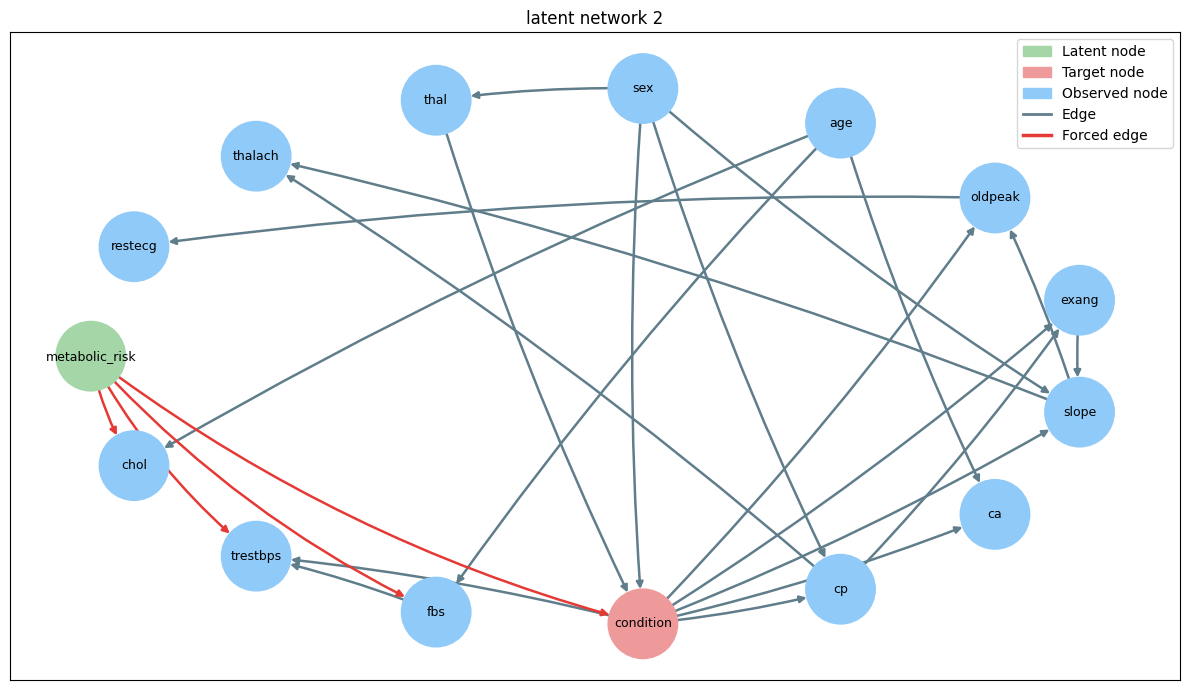

In [ ]:
forced_edges_2 = [
    ('metabolic_risk', 'chol'),
    ('metabolic_risk', 'trestbps'),
    ('metabolic_risk', 'fbs'),
    ('metabolic_risk', 'condition'),
]
latent_nodes_2 = ['metabolic_risk']


acc_2, recall_2, latent_model_2 = kfold_latent(df, forbidden_edges, forced_edges_2, latent_nodes_2, target_col='condition')

plot_latent_network(latent_model_2.edges(), forced_edges=forced_edges_2, latent_nodes=latent_nodes_2, target='condition', title='latent network 2', legend_loc='upper right')

### Network 3

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
/home/liam/pythonEnvs/env1/lib/python3.11/site-packages/pgmpy/factors/discrete/DiscreteFactor.py:489: RuntimeWarning: invalid value encountered in divide
  phi.values = phi.values / (phi.values.sum())
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C'

  Fold 1: Accuracy=0.617, Recall=0.571


  0%|          | 0/1000000 [00:00<?, ?it/s]

...

  Fold 4: Accuracy=0.746, Recall=0.704


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'thal': 'N', 'condition': 'N'}


  Fold 5: Accuracy=0.797, Recall=0.741
  MEAN -> Accuracy=0.731, Recall=0.679



/home/liam/pythonEnvs/env1/lib/python3.11/site-packages/pgmpy/factors/discrete/DiscreteFactor.py:489: RuntimeWarning: invalid value encountered in divide
  phi.values = phi.values / (phi.values.sum())


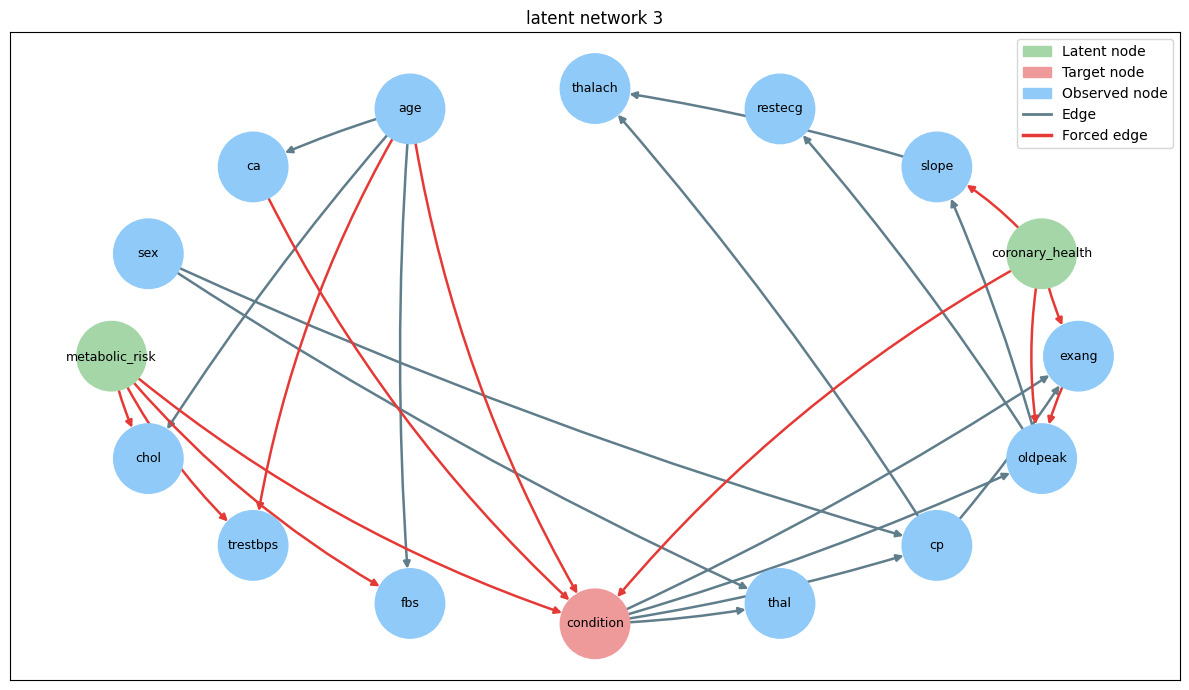

In [ ]:
forced_edges_3 = [
    ('metabolic_risk', 'chol'),
    ('metabolic_risk', 'trestbps'),
    ('metabolic_risk', 'fbs'),
    ('metabolic_risk', 'condition'),
    ('age', 'condition'),
    ('age', 'trestbps'),
    ('exang', 'oldpeak'),
    ('ca', 'condition'),
    ('coronary_health', 'oldpeak'),
    ('coronary_health', 'exang'),
    ('coronary_health', 'slope'),
    ('coronary_health', 'condition'),]

latent_nodes_3 = latent_nodes_1 + latent_nodes_2


acc_3, recall_3, latent_model_3 = kfold_latent(df, forbidden_edges, forced_edges_3, latent_nodes_3, target_col='condition')

plot_latent_network(latent_model_3.edges(), forced_edges=forced_edges_3, latent_nodes=latent_nodes_3, target='condition', title='latent network 3', legend_loc='upper right')

Ultimately, we performed a comparative analysis of the three architectures to identify the optimal structure. The evaluation was based on Bayesian scoring metrics and the model's ability to represent the underlying clinical data accurately.


In [ ]:
from plot_functions import plot_grouped_bars

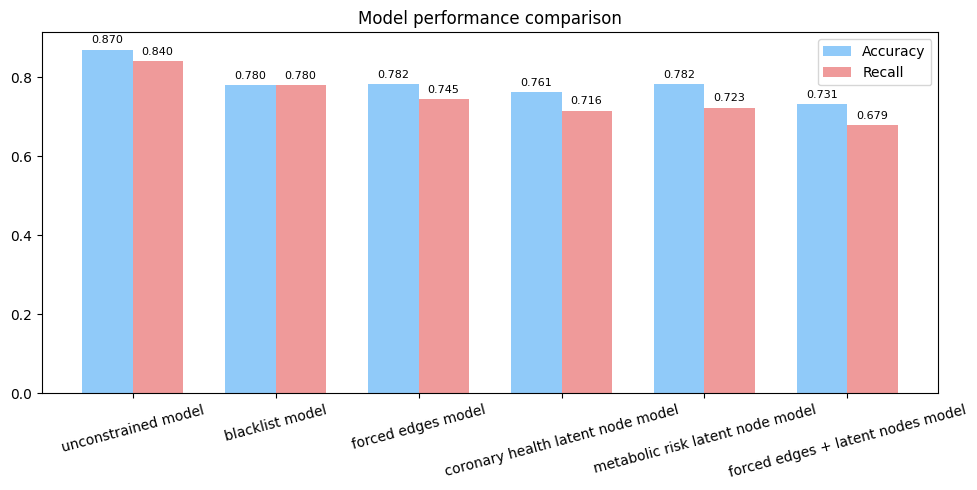

In [ ]:
fig, ax = plot_grouped_bars(models, accs, recalls,
                           metric_labels=('Accuracy', 'Recall'), title='Model performance comparison', rotation=15)

____________________________________________________________

## 3.4 Cross test on Indian Heart Dataset

### Indian Heart dataset Preprocessing

In [ ]:
df_indian = pd.read_csv("datasets/Indian_heart_disease_dataset.csv")

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

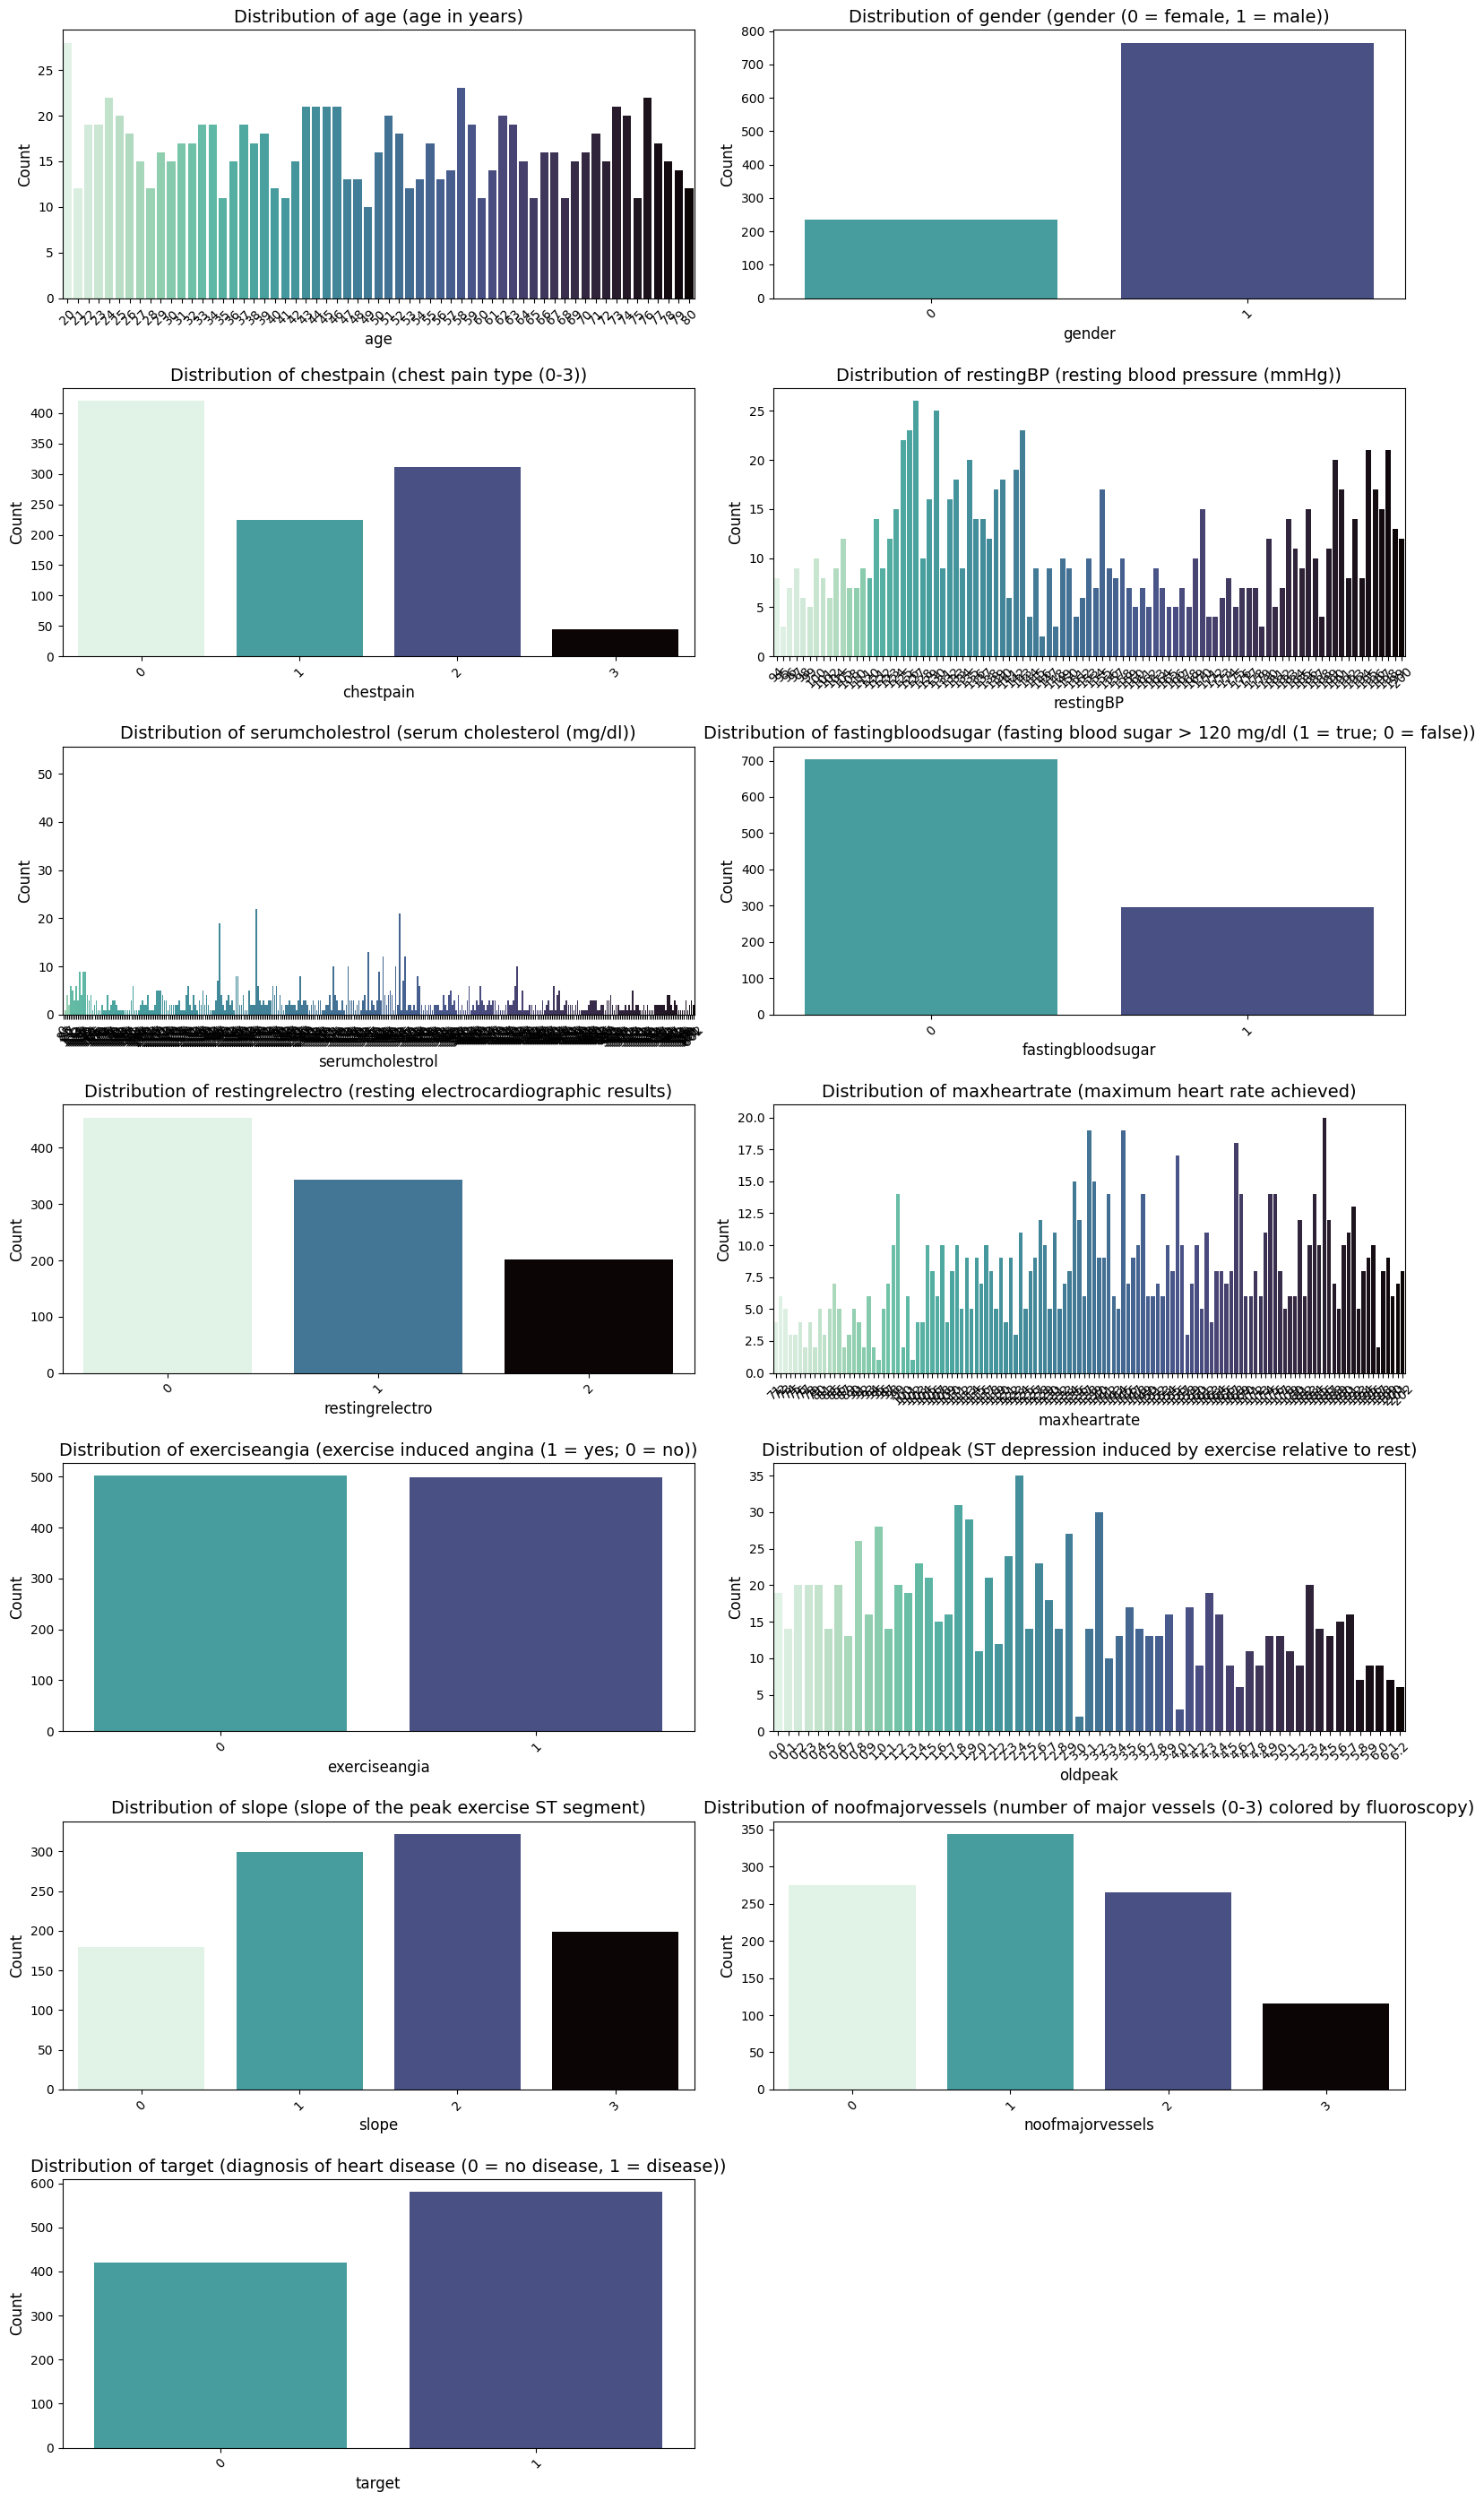

In [ ]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(16, 28))
axes = axes.flatten()

column_descriptions = {
    'age': 'age in years',
    'gender': 'gender (0 = female, 1 = male)',
    'chestpain': 'chest pain type (0-3)',
    'restingBP': 'resting blood pressure (mmHg)',
    'serumcholestrol': 'serum cholesterol (mg/dl)',
    'fastingbloodsugar': 'fasting blood sugar > 120 mg/dl (1 = true; 0 = false)',
    'restingrelectro': 'resting electrocardiographic results',
    'maxheartrate': 'maximum heart rate achieved',
    'exerciseangia': 'exercise induced angina (1 = yes; 0 = no)',
    'oldpeak': 'ST depression induced by exercise relative to rest',
    'slope': 'slope of the peak exercise ST segment',
    'noofmajorvessels': 'number of major vessels (0-3) colored by fluoroscopy',
    'target': 'diagnosis of heart disease (0 = no disease, 1 = disease)'
}

columns_to_plot = [c for c in df_indian.columns if c != 'patientid']

for i, column in enumerate(columns_to_plot):
    sns.countplot(data=df_indian, x=column, hue=column, ax=axes[i], palette='mako_r', legend=False)
    title = f'Distribution of {column}'
    if column in column_descriptions:
        title += f' ({column_descriptions[column]})'
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(columns_to_plot), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
df_indian = pd.read_csv("datasets/Indian_heart_disease_dataset.csv")

# Drop patientid - not a clinical feature
df_indian = df_indian.drop(columns=['patientid'])

# Remove rows with invalid cholesterol
print(f"Rows before cleaning: {len(df_indian)}")
df_indian = df_indian[df_indian['serumcholestrol'] != 0].copy()
print(f"Rows after cleaning: {len(df_indian)}")

Rows before cleaning: 1000
Rows after cleaning: 947


In [ ]:
old_columns = df_indian.columns.difference(['age', 'slope', 'oldpeak'])

# Resting Blood Pressure (mmHg)
# Source: AHA Hypertension Guidelines
bins_trestbps = [0, 119, 129, 139, 180, df_indian['restingBP'].max() + 1]
labels_trestbps = ['0-118 Normal', '119-128 Elevated', '129-138 Hypertension Stage 1', '139-179 Hypertension Stage 2', '>=180 Hypertensive Crisis']
df_indian['trestbps'] = pd.cut(df_indian['restingBP'], bins=bins_trestbps, labels=labels_trestbps, right=False)

# Gender
df_indian['sex'] = df_indian['gender'].map({0: 'Female', 1: 'Male'})

# Serum Cholesterol (mg/dl)
# Source: NHLBI ATP III Guidelines
bins_chol = [df_indian['serumcholestrol'].min(), 200, 240, df_indian['serumcholestrol'].max() + 1]
labels_chol = ['<200 Desirable', '200-239 Borderline High', '>=240 High']
df_indian['chol'] = pd.cut(df_indian['serumcholestrol'], bins=bins_chol, labels=labels_chol, right=False)

# Age
# Source: Global Burden of Disease Study / The Lancet
bins_age = [df_indian['age'].min(), 40, 50, 60, 70, df_indian['age'].max() + 1]
labels_age = ['<= 39', '40 - 49', '50 - 59', '60 - 69', '>= 70']
df_indian['age'] = pd.cut(df_indian['age'], bins=bins_age, labels=labels_age, right=False)

# Max Heart Rate (bpm)
bins_thalach = [df_indian['maxheartrate'].min(), 120, 151, 181, df_indian['maxheartrate'].max() + 1]
labels_thalach = ['>=181 High', '151-180 Optimal', '120-150 Moderate', '<120 Poor Response'] # Reversed order
df_indian['thalach'] = pd.cut(df_indian['maxheartrate'], bins=bins_thalach, labels=labels_thalach, right=False)

# Oldpeak (ST depression)
# Source: Wikipedia - ST depression
bins_oldpeak = [df_indian['oldpeak'].min() - 0.001, 0.001, 1.0, 2.0, df_indian['oldpeak'].max() + 1]
labels_oldpeak = ['0 Optimal', '0.1-0.9 Low Risk', '1.0-1.9 Moderate Risk', '>=2.0 High Risk']
df_indian['oldpeak'] = pd.cut(df_indian['oldpeak'], bins=bins_oldpeak, labels=labels_oldpeak, right=False)

# Fasting Blood Sugar
df_indian['fbs'] = df_indian['fastingbloodsugar'].map({0: 'Normal', 1: 'High'})

# Resting ECG
df_indian['restecg'] = df_indian['restingrelectro'].map({0: 'Normal', 1: 'ST-T Abnormality', 2: 'LV Hypertrophy'})

# Exercise Angina
df_indian['exang'] = df_indian['exerciseangia'].map({0: 'No', 1: 'Yes'})

# Chest Pain Type
df_indian['cp'] = df_indian['chestpain'].map({
    0: 'Typical Angina',
    1: 'Atypical Angina',
    2: 'Non-Anginal Pain',
    3: 'Asymptomatic'
})

# Slope
# Value 3 has no standard clinical meaning and is removed
df_indian['slope'] = df_indian['slope'].map({
    0: 'Upsloping',
    1: 'Flat',
    2: 'Downsloping'
})

df_indian['ca'] = df_indian['noofmajorvessels']

df_indian['condition'] = df_indian['target']


# Drop remaining NaN rows
df_indian = df_indian.dropna()

df_indian = df_indian.drop(columns=old_columns)

print(f"Final dataset: {len(df_indian)} rows, columns: {df_indian.columns}")
print()

Final dataset: 765 rows, columns: Index(['age', 'oldpeak', 'slope', 'trestbps', 'sex', 'chol', 'thalach', 'fbs',
       'restecg', 'exang', 'cp', 'ca', 'condition'],
      dtype='object')



INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


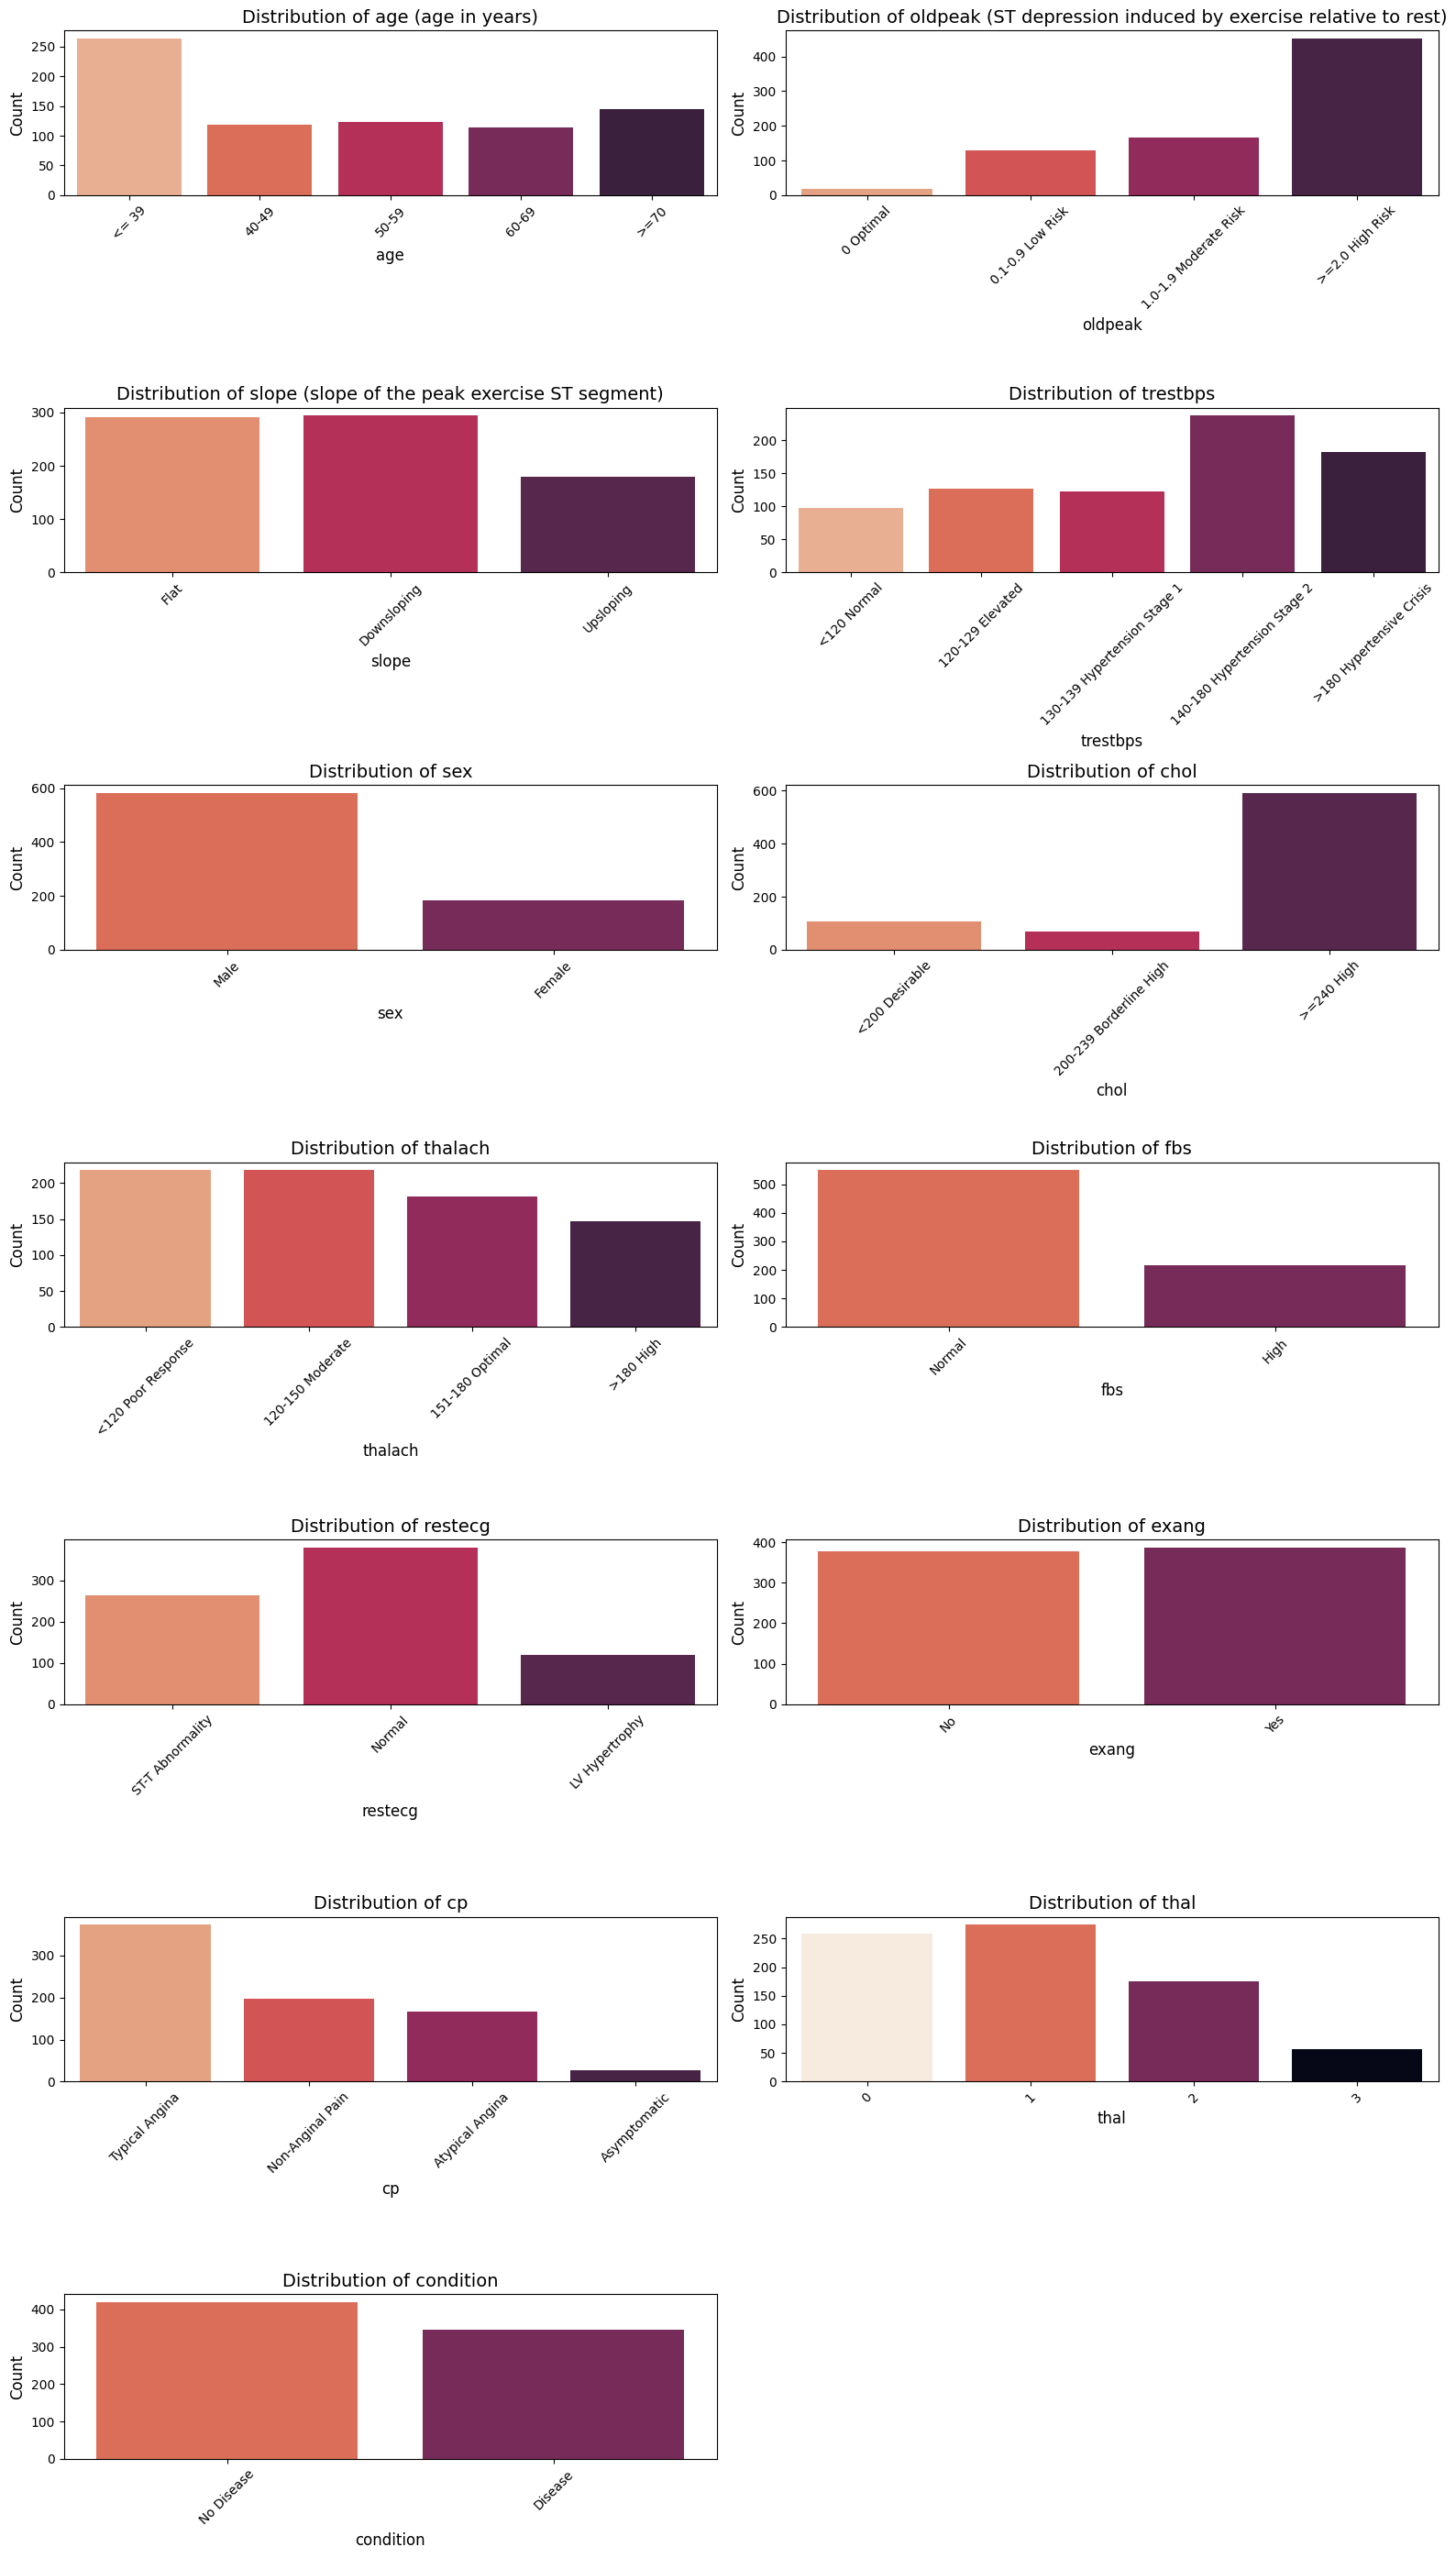

In [ ]:
fig, axes = plt.subplots(nrows=7, ncols=2, figsize=(16, 28))
axes = axes.flatten()

for i, column in enumerate(df_indian.columns):
    sns.countplot(data=df_indian, x=column, hue=column, ax=axes[i], palette='rocket_r', legend=False)
    title = f'Distribution of {column}'
    if column in column_descriptions:
        title += f' ({column_descriptions[column]})'
    axes[i].set_title(title, fontsize=14)
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(df_indian.columns), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### Cross test results

In [ ]:
acc_indian, recall_indian = evaluate_latent_model(latent_model_1, df_indian, target_col='condition', latent_nodes=latent_nodes_1)


In [ ]:
acc_indian

0.5398692810457516

In [ ]:
recall_indian

np.float64(0.5739130434782609)

The latent node model trained on the Cleveland dataset shows a substantial drop in performance when evaluated on the Indian Heart dataset

### Unconstrained network trained on Indian Heart dataset

In [ ]:
# from network_functions module
def create_model(train_set, estimator, forbidden_edges=None, forced_edges=None):

    df = train_set

    scoring_method = estimator(df)

    hc = HillClimbSearch(df)

    best_model = hc.estimate(scoring_method=scoring_method,
                    expert_knowledge=ExpertKnowledge(forbidden_edges=forbidden_edges))

    learned_model = DiscreteBayesianNetwork(best_model.edges())

    learned_model.fit(df, estimator=BayesianEstimator, prior_type="BDeu")

    learned_model.check_model()

    return learned_model

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'condition': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'condition': 'N'}


  0%|          | 0/1000000 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'age': 'O', 'sex': 'O', 'cp': 'C', 'trestbps': 'O', 'chol': 'O', 'fbs': 'C', 'restecg': 'C', 'thalach': 'O', 'exang': 'C', 'oldpeak': 'O', 'slope': 'C', 'ca': 'N', 'condition': 'N'}


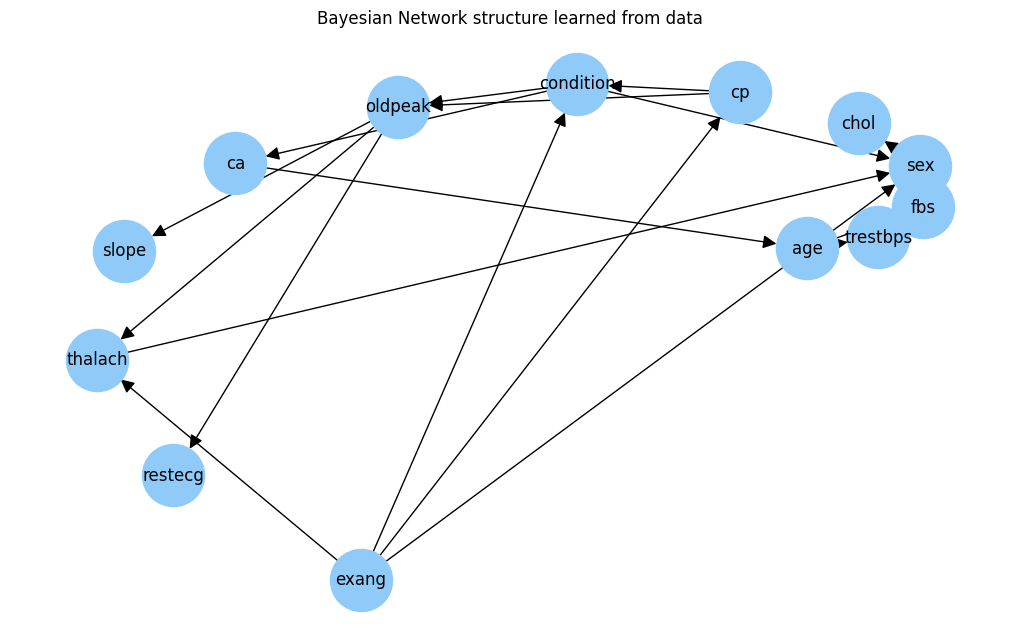

Missing nodes: set()
accuracy:  0.6784313725490196
recall:  0.8028985507246377


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from pgmpy.estimators import HillClimbSearch, AIC
from pgmpy.estimators import BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination
import networkx as nx
from network_functions import create_model, plot_network

# Split train/test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["condition"])

base_model = create_model(train_df, AIC)

plot_network(base_model)

base_model_acc, base_model_recall = evaluate_model(base_model, df_indian, target_col='condition')
print("accuracy: ", base_model_acc)
print("recall: ", base_model_recall)

By analyzing the network learned from the Indian database, we observe that, consistent with the Cleveland dataset, the heart condition is directly influenced by cp (chest pain) and exang (exercise-induced angina). This consistency across two distinct datasets, collected in different social contexts and time periods (1989 vs. 2021), suggests that these chest-pain-related features are highly robust and universal predictors of coronary artery disease, regardless of demographic or temporal variations.